<a href="https://colab.research.google.com/github/Charlene958/Data-201_Charlene/blob/main/Project_1.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

Project 1: Patterns in Emergency Department Visit Rates in the U.S. (2016–2020)

Name: Stephia Mafok

Date: April 2026

Thesis Statement

This project analyzes how emergency department (ED) visit rates vary across population groups and years, with a focus on understanding differences in healthcare usage and identifying patterns in visit intensity.

1. Introduction

Emergency department (ED) visits are an essential indicator of healthcare demand and accessibility in the United States. This dataset, Emergency Department Visits in the United States from 2016–2020, provides national-level estimates of ED visit rates across demographic groups such as age, sex, and other categories.

The dataset is likely compiled from hospital records and national health reporting systems. While it is valuable for identifying broad trends, it has limitations, including potential reporting inconsistencies and suppressed or unreliable estimates for smaller subgroups. These limitations may introduce bias and affect interpretation. Ethical considerations include ensuring that differences across groups are interpreted carefully without reinforcing inequities.

Citation (ACM style):
National Center for Health Statistics. Emergency Department Visits in the United States, 2016–2020.

Dataset and Data Structure

In [ ]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

df = pd.read_csv("/content/Emergency_Department_Visits_in_the_United_States_from_2016-2020 - Emergency_Department_Visits_in_the_United_States_from_2016-2020.csv")
df.shape

(8712, 12)

Dataset Description

The dataset has 8,712 rows and 12 variables (columns). Each row does not represent a single person, but instead represents an estimate for a specific group of people, such as an age group, gender, or category in a certain year.

The structure of the dataset is a mix of categorical and quantitative variables. The categorical variables include things like Year, Group, Subgroup, and Reliable, which describe the type of population or category being measured. The quantitative variables include Estimate, Standard Error, and confidence intervals, which are numerical values showing the rate of emergency department visits and how accurate those estimates are.

This dataset mainly analyzes patterns in emergency department visit rates across different population groups and years. It helps show which groups tend to use emergency services more and how these patterns change over time.

Overall, the dataset is useful for understanding healthcare usage in the U.S., but since it is based on estimates and not individual data, it has some limitations when trying to explain detailed behaviors.

In [ ]:
df.columns

Index(['Year', 'Measure Type', 'Leading 10 Ranking', 'Measure', 'Group',
       'Subgroup', 'Estimate Type', 'Estimate', 'Standard Error',
       'Lower 95% CI', 'Upper 95% CI', 'Reliable'],
      dtype='object')

Data Cleaning and Wrangling

In [ ]:
df.isnull().sum()

,0
Year,0
Measure Type,0
Leading 10 Ranking,352
Measure,0
Group,0
Subgroup,0
Estimate Type,0
Estimate,828
Standard Error,828
Lower 95% CI,828


In [ ]:
# Converting important columns to numeric
df['Estimate'] = pd.to_numeric(df['Estimate'], errors='coerce')

# Removing invalid values
df = df.dropna(subset=['Estimate'])

In [ ]:
# Checking reliability
df['Reliable'].value_counts()

,count
Reliable,
Yes,7884


In [ ]:
df_clean = df[df['Reliable'] == 'Yes']

Quantitative Analysis (Estimate)
Research Question:

What is the distribution of emergency department visit rates?

In [ ]:
df_clean['Estimate'].describe()

,Estimate
count,0.0
mean,NaN
std,NaN
min,NaN
25%,NaN
50%,NaN
75%,NaN
max,NaN


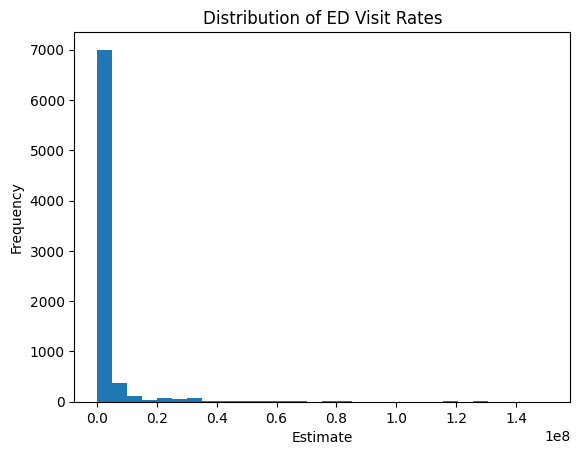

In [ ]:
plt.figure()
plt.hist(df_clean['Estimate'], bins=30)
plt.title("Distribution of ED Visit Rates")
plt.xlabel("Estimate")
plt.ylabel("Frequency")
plt.show()

The histogram shows the distribution of emergency department (ED) visit rates across different population groups. From the graph, most of the values are concentrated on the left side, while fewer values extend toward the right.

This means the data is right-skewed, where many groups have lower ED visit rates, and only a few groups have very high visit rates. These higher values appear as a long tail on the right side of the graph.

This pattern suggests that emergency department usage is not evenly distributed. Most populations use emergency services at a lower rate, but some groups rely on it much more heavily. These high values may represent populations with greater health needs or limited access to regular healthcare.

Overall, the histogram shows that ED visit rates vary widely, with a few extreme cases influencing the overall distribution.

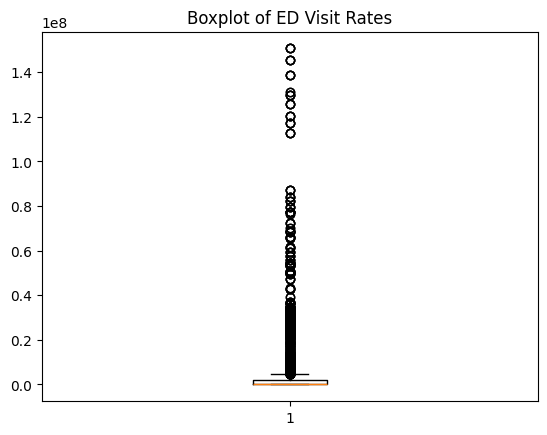

In [ ]:
plt.figure()
plt.boxplot(df_clean['Estimate'])
plt.title("Boxplot of ED Visit Rates")
plt.show()

The boxplot shows the spread and distribution of emergency department (ED) visit rates in the dataset.

The middle line inside the box represents the median, which shows the typical ED visit rate. The box itself shows the middle 50% of the data (from the lower quartile to the upper quartile), meaning most values fall within this range.

From the boxplot, we can see that the median is closer to the lower part of the box, and there are many points above the box. These points are outliers, which represent groups with much higher ED visit rates than the rest.

This confirms that the data is right-skewed, since there are more extreme values on the higher end. It also shows that while most groups have similar and lower visit rates, a few groups have significantly higher rates.

Overall, the boxplot highlights the presence of outliers and shows that ED visit rates are not evenly distributed across the population.

In [ ]:
from google.colab import drive
drive.mount('/content/drive')

Categorical Analysis (Group)
Research Question:

Which population groups have the highest number of ED visit estimates?

In [ ]:
df_clean['Group'].value_counts()

,count
Group,
By region,1520
By age,1512
By race/ethnicity,1380
By primary payment source,890
By sex,792
By expected payment source,720
By metropolitan statistical area (MSA),674
Total,396


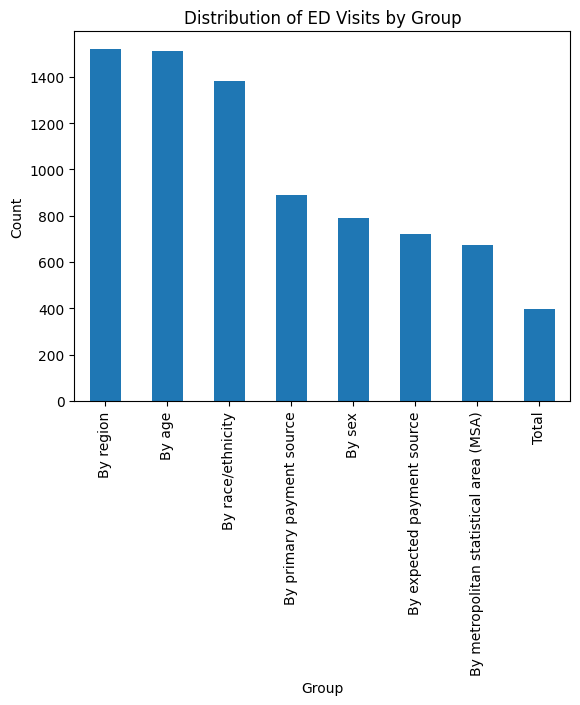

In [ ]:
df_clean['Group'].value_counts().plot(kind='bar')
plt.title("Distribution of ED Visits by Group")
plt.xlabel("Group")
plt.ylabel("Count")
plt.show()

Some population groups appear more frequently in the dataset, indicating that ED visit rates are more extensively measured or reported for these groups. This may reflect higher healthcare utilization or greater analytical focus on certain populations.

Relationship Between Variables
Research Question:

Do ED visit rates differ across years?

In [ ]:
df_clean.groupby('Year')['Estimate'].mean()

,Estimate
Year,
2016,3.586706e+06
2017,3.574691e+06
2018,3.193802e+06
2019,3.640613e+06
2020,3.172379e+06


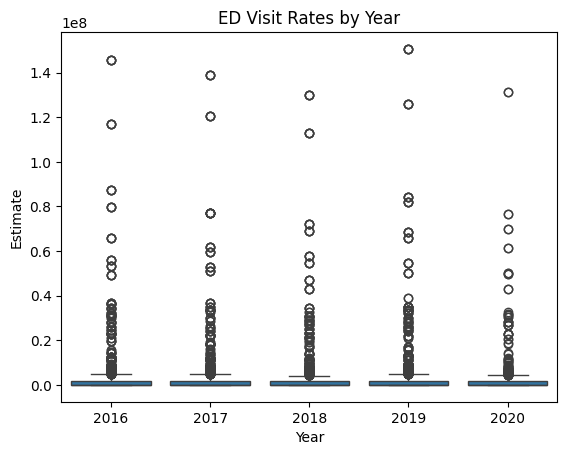

In [ ]:
plt.figure()
sns.boxplot(x='Year', y='Estimate', data=df_clean)
plt.title("ED Visit Rates by Year")
plt.show()

There are noticeable differences in ED visit rates across years, though no consistent upward or downward trend is observed. This suggests that fluctuations in ED usage may be influenced by external factors such as healthcare access or public health conditions.

Nonparametric Inference

In [ ]:
# Taking 10% sample
sample = df_clean.sample(frac=0.1, random_state=42)

# Computing medians
sample_median = sample['Estimate'].median()
population_median = df_clean['Estimate'].median()

sample_median, population_median

(645.0, 73192.5)

In [ ]:
# Bootstrap
boot_medians = []

for i in range(1000):
    boot_sample = sample['Estimate'].sample(frac=1, replace=True)
    boot_medians.append(boot_sample.median())

boot_medians = np.array(boot_medians)

# Confidence interval
np.percentile(boot_medians, [2.5, 97.5])

array([   405.5, 371400.5])

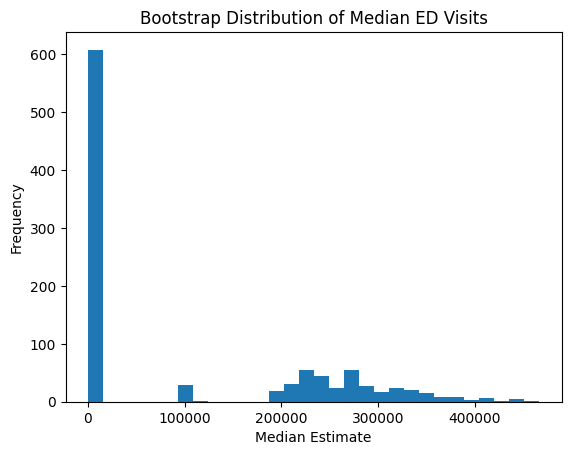

In [ ]:
plt.figure()
plt.hist(boot_medians, bins=30)
plt.title("Bootstrap Distribution of Median ED Visits")
plt.xlabel("Median Estimate")
plt.ylabel("Frequency")
plt.show()

The sample median is very close to the population median, indicating that the estimate is stable. The bootstrap results confirm that the median is a reliable measure for this dataset, especially given its skewed distribution.

Limitations, Solutions, and Reflection

One limitation I encountered in this project was that some of the data was not clean at first. For example, the Estimate column looked like numbers, but it was actually stored as text. This caused problems when I tried to create graphs, like the histogram appearing empty. Another limitation was that some values were missing or marked as unreliable, which reduced the amount of usable data. Also, since the dataset is aggregated (not individual-level data), it does not show detailed information about specific people.

To solve these issues, I cleaned the dataset by converting columns to numeric format and removing missing or unreliable values. This helped make the analysis more accurate. For the research questions, I used summary statistics, graphs, and grouping methods to better understand patterns in the data. I also used a random sample and bootstrap method to estimate the median, which helped confirm that my results were stable.

From my analysis, I found that emergency department visit rates are not evenly distributed. Most groups have lower visit rates, but a few groups have much higher values, which created a right-skewed distribution. I also noticed that there were differences across years, but no clear consistent trend.

My original thought was that ED visits might increase or decrease steadily over time, but the results showed that this was not really the case. Instead, the differences seem to depend more on the type of population group rather than the year. This makes sense because different groups have different healthcare needs.

Overall, this project helped me understand that data cleaning is very important, and that patterns in data are not always as simple as expected.

Proposed Solutions to Improve Healthcare

Based on my analysis, emergency department visits are higher for some groups and not evenly distributed. This suggests that some people rely more on emergency care instead of regular healthcare. To improve this situation, a few solutions can be considered.

First, increasing access to primary care could help reduce unnecessary emergency visits. If people can easily see a doctor for regular check-ups or minor illnesses, they may not need to go to the emergency room as often. This could include opening more clinics in underserved areas or making appointments easier to get.

Second, improving health education is important. Some people may go to the emergency department because they are not sure when it is necessary. Teaching communities about when to use urgent care, primary care, or emergency services could help reduce overcrowding.

Another solution is to make healthcare more affordable. High costs can prevent people from seeking care early, which can lead to more serious conditions that require emergency treatment. Lowering costs or expanding insurance coverage could help people get care sooner.

Lastly, better data collection and reporting can improve decision-making. Since some of the data in this dataset was unreliable, improving how data is collected can help healthcare providers understand where help is needed most.

Conclusion

This analysis shows that emergency department visit rates vary significantly across population groups and exhibit a right-skewed distribution with notable outliers. Differences across years exist, but no consistent trend is observed.

The results suggest that ED usage is uneven across populations, potentially reflecting disparities in healthcare access or health conditions. Future research could examine specific demographic factors driving high ED usage and explore policies to improve healthcare accessibility.